# Evaluation Statistics (Summary)

This notebook loads a per-instance evaluation summary CSV (typically produced by `dataset_analysis.ipynb`) and prints statistical summaries over sensible parameter subsets.

Key design points:
- **Success metrics** (like `success_rate`) use all rows.
- **Evaluation metrics** (`eval_advantage`, `eval_correlation`, `eval_hamming_frac`) are computed **only on rows where they are present**.
- For `rho = 0`, ground truth may not exist, so evaluation metrics may be missing — those rows are **excluded from metric aggregates** but still included in success statistics.

Outputs written (overwritten on each run):
- `logs/eval_stats.log` (human-readable report with explanations)
- `logs/eval_stats.csv` (tidy machine-readable summary)


In [ ]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

BASE = Path('.').resolve()
LOG_DIR = BASE / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / 'eval_stats_quantum.log'
OUT_CSV = LOG_DIR / 'eval_stats_quantum.csv'

DEFAULT_INPUT = BASE / 'logs' / 'summary_all_instances_quantum.csv'

INPUT_CSV: Optional[Path] = None

def _pick_input_csv() -> Path:
    if INPUT_CSV is not None:
        p = Path(INPUT_CSV)
        if p.exists():
            return p
        raise FileNotFoundError(f'INPUT_CSV does not exist: {p}')
    if DEFAULT_INPUT.exists():
        return DEFAULT_INPUT
    candidates = sorted(LOG_DIR.glob('**/*summary*.csv')) + sorted(LOG_DIR.glob('**/*results*.csv'))
    candidates = [p for p in candidates if p.is_file()]
    if not candidates:
        raise FileNotFoundError(
            'Could not find an input CSV. Expected one of: '
            f'{DEFAULT_INPUT} or something like logs/**/*summary*.csv'
        )
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

IN_CSV = _pick_input_csv()
print('Input CSV:', str(IN_CSV))
print('Log file :', str(LOG_FILE))
print('Out CSV  :', str(OUT_CSV))

Input CSV: /Users/julian/CodingProjects/UniT3/QuarticSpeedupK-XOR/logs/summary_all_instances_quantum.csv
Log file : /Users/julian/CodingProjects/UniT3/QuarticSpeedupK-XOR/logs/eval_stats_quantum.log
Out CSV  : /Users/julian/CodingProjects/UniT3/QuarticSpeedupK-XOR/logs/eval_stats_quantum.csv


In [ ]:

def _coerce_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    lowered = s.astype(str).str.strip().str.lower()
    return lowered.isin({'true', '1', 'yes', 'y'})

def _to_numeric(df: pd.DataFrame, cols: Iterable[str]) -> None:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

df_raw = pd.read_csv(IN_CSV)
df = df_raw.copy()
print('Loaded rows:', len(df))
print('Columns:', sorted(df.columns.tolist()))

if 'failed' in df.columns:
    df['failed'] = _coerce_bool_series(df['failed'])
else:
    df['failed'] = False
df['success'] = ~df['failed']

param_cols = ['n', 'k', 'm', 'ell', 'eps', 'kappa', 'rho']
_to_numeric(df, param_cols)

metric_cols = ['eval_advantage', 'eval_correlation', 'eval_hamming_frac']
_to_numeric(df, metric_cols)

if 'eval_advantage' in df.columns:
    df['eval_bit_accuracy_est'] = (1.0 + df['eval_advantage']) / 2.0
    metric_cols.append('eval_bit_accuracy_est')

metrics_present = [m for m in metric_cols if m in df.columns]
print('Success rate:', float(df['success'].mean()) if len(df) else float('nan'))
print('Metrics present:', metrics_present)

if 'rho' in df.columns and int((df['rho'] == 0).sum()) > 0:
    rho0 = df[df['rho'] == 0]
    print(f"rho=0 rows: {int(len(rho0))} (success {int(rho0['success'].sum())}/{int(len(rho0))})")
    for m in metrics_present:
        n_present = int(rho0[rho0['success']][m].notna().sum())
        print(f"  rho=0 metric-present {m}: {n_present}")

Loaded rows: 174
Columns: ['ell', 'eps', 'eval_advantage', 'eval_correlation', 'eval_hamming_frac', 'failed', 'k', 'kappa', 'len_z_hat', 'log_file', 'm', 'n', 'path', 'rho', 'stage2_backend', 'stem']
Success rate: 1.0
Metrics present: ['eval_advantage', 'eval_correlation', 'eval_hamming_frac', 'eval_bit_accuracy_est']
rho=0 rows: 29 (success 29/29)
  rho=0 metric-present eval_advantage: 29
  rho=0 metric-present eval_correlation: 0
  rho=0 metric-present eval_hamming_frac: 0
  rho=0 metric-present eval_bit_accuracy_est: 29


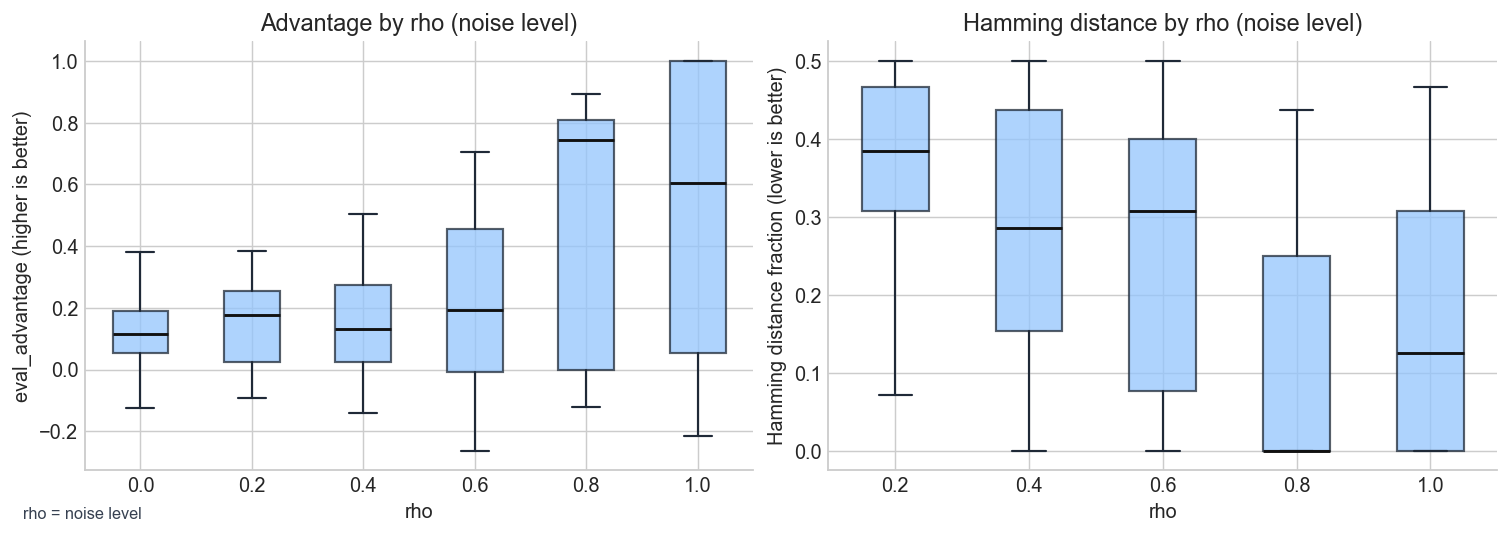

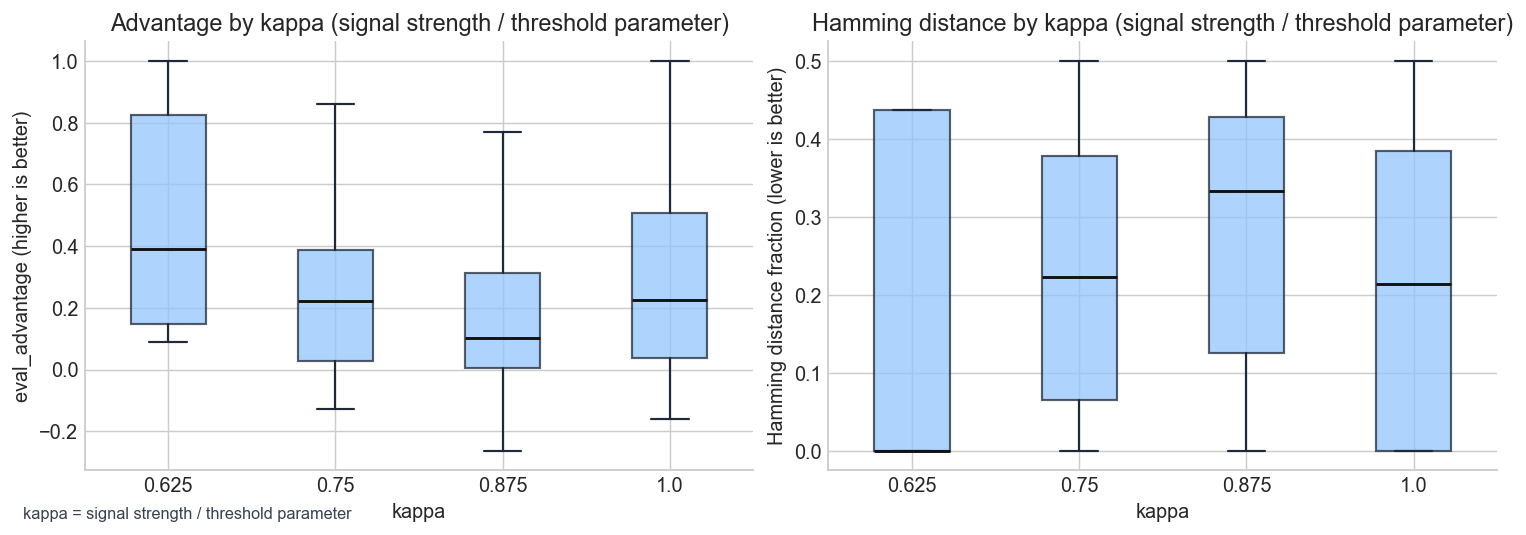

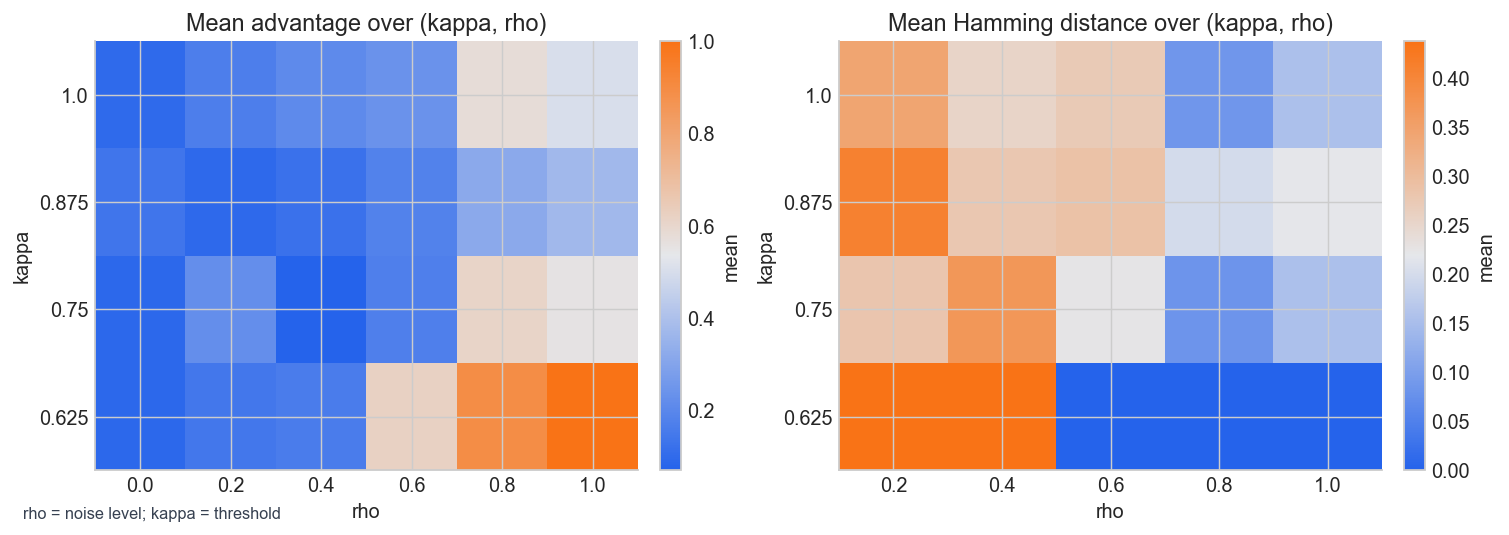

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

CMAP_BLUE_GREY_ORANGE = LinearSegmentedColormap.from_list(
    "blue_grey_orange", ["#2563eb", "#e5e7eb", "#f97316"]
)

df_succ = df[df["success"]].copy()

if "eval_hamming_frac" in df_succ.columns:
    df_succ["eval_hamming_distance_frac"] = df_succ["eval_hamming_frac"]


def _boxplot_by(
    ax,
    df_in: pd.DataFrame,
    *,
    group_col: str,
    value_col: str,
    title: str,
    ylabel: str,
 ) -> None:
    d = df_in[[group_col, value_col]].dropna().copy()
    if d.empty:
        ax.set_axis_off()
        ax.set_title(f"{title} (no data)")
        return

    groups = sorted(d[group_col].unique())
    data = [d.loc[d[group_col] == g, value_col].to_numpy() for g in groups]

    bp = ax.boxplot(
        data,
        tick_labels=[str(g) for g in groups],
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "#111111", "linewidth": 1.6},
        boxprops={"linewidth": 1.2, "color": "#1f2937"},
        whiskerprops={"linewidth": 1.2, "color": "#1f2937"},
        capprops={"linewidth": 1.2, "color": "#1f2937"},
    )
    for b in bp["boxes"]:
        b.set_facecolor("#93c5fd")
        b.set_alpha(0.75)

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(ylabel)


def _heatmap_mean(
    ax,
    df_in: pd.DataFrame,
    *,
    row: str,
    col: str,
    value: str,
    title: str,
    cmap: str,
 ) -> None:
    d = df_in[[row, col, value]].dropna().copy()
    if d.empty:
        ax.set_axis_off()
        ax.set_title(f"{title} (no data)")
        return

    pivot = (
        d.pivot_table(index=row, columns=col, values=value, aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )

    im = ax.imshow(pivot.to_numpy(), aspect="auto", origin="lower", cmap=cmap)

    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel(row)

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([str(x) for x in pivot.columns], rotation=0)

    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels([str(y) for y in pivot.index])

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("mean", rotation=90)


def _two_metric_boxplots(df_in: pd.DataFrame, *, group_col: str, definition: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)

    fig.text(
        0.01,
        0.01,
        f"{group_col} = {definition}",
        ha="left",
        va="bottom",
        fontsize=9,
        color="#374151",
    )

    if group_col in df_in.columns and "eval_advantage" in df_in.columns:
        _boxplot_by(
            axes[0],
            df_in,
            group_col=group_col,
            value_col="eval_advantage",
            title=f"Advantage by {group_col} ({definition})",
            ylabel="eval_advantage (higher is better)",
        )
    else:
        axes[0].set_axis_off()
        axes[0].set_title(f"Advantage by {group_col} (missing columns)")

    if group_col in df_in.columns and "eval_hamming_distance_frac" in df_in.columns:
        _boxplot_by(
            axes[1],
            df_in,
            group_col=group_col,
            value_col="eval_hamming_distance_frac",
            title=f"Hamming distance by {group_col} ({definition})",
            ylabel="Hamming distance fraction (lower is better)",
        )
    else:
        axes[1].set_axis_off()
        axes[1].set_title(f"Hamming distance by {group_col} (missing columns)")

    plt.show()

PARAM_DEFS = {
    "rho": "noise level",
    "kappa": "signal strength / threshold parameter",
}

for col, meaning in PARAM_DEFS.items():
    _two_metric_boxplots(df_succ, group_col=col, definition=meaning)

if "kappa" in df_succ.columns and "rho" in df_succ.columns:
    fig2, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)
    fig2.text(0.01, 0.01, "rho = noise level; kappa = threshold", ha="left", va="bottom", fontsize=9, color="#374151")

    if "eval_advantage" in df_succ.columns:
        _heatmap_mean(
            axes[0],
            df_succ,
            row="kappa",
            col="rho",
            value="eval_advantage",
            title="Mean advantage over (kappa, rho)",
            cmap=CMAP_BLUE_GREY_ORANGE,
        )
    else:
        axes[0].set_axis_off()
        axes[0].set_title("Mean advantage heatmap (missing column)")

    if "eval_hamming_distance_frac" in df_succ.columns:
        _heatmap_mean(
            axes[1],
            df_succ,
            row="kappa",
            col="rho",
            value="eval_hamming_distance_frac",
            title="Mean Hamming distance over (kappa, rho)",
            cmap=CMAP_BLUE_GREY_ORANGE,
        )
    else:
        axes[1].set_axis_off()
        axes[1].set_title("Mean Hamming distance heatmap (missing column)")

    plt.show()
else:
    print("(plots) Skipping (kappa, rho) heatmaps: need both columns present.")


In [ ]:

def _quantiles(x: pd.Series, qs: Sequence[float]) -> Dict[str, float]:
    x2 = x.dropna()
    if x2.empty:
        return {f'p{int(q*100)}': float('nan') for q in qs}
    res = x2.quantile(qs).to_dict()
    return {f'p{int(q*100)}': float(res[q]) for q in qs}

def summarize_metric(x: pd.Series) -> Dict[str, Any]:
    x2 = x.dropna()
    out: Dict[str, Any] = {
        'n_metric': int(x2.shape[0]),
        'mean': float(x2.mean()) if not x2.empty else float('nan'),
        'median': float(x2.median()) if not x2.empty else float('nan'),
        'var': float(x2.var(ddof=1)) if x2.shape[0] >= 2 else float('nan'),
        'std': float(x2.std(ddof=1)) if x2.shape[0] >= 2 else float('nan'),
        'min': float(x2.min()) if not x2.empty else float('nan'),
        'max': float(x2.max()) if not x2.empty else float('nan'),
    }
    qs = _quantiles(x2, [0.10, 0.25, 0.50, 0.75, 0.90])
    out.update(qs)
    out['iqr'] = float(out['p75'] - out['p25']) if (not math.isnan(out['p25']) and not math.isnan(out['p75'])) else float('nan')
    return out

def summarize_group(
    df_all: pd.DataFrame,
    *,
    group_cols: Sequence[str],
    group_name: str,
    explanation: str,
    metrics: Sequence[str],
    max_groups: int = 50,
) -> Tuple[pd.DataFrame, str]:
    missing = [c for c in group_cols if c not in df_all.columns]
    if missing:
        return pd.DataFrame(), f"SKIP {group_name}: missing columns {missing}\n"
    distinct = df_all.dropna(subset=list(group_cols))
    ngroups = int(distinct.groupby(list(group_cols)).ngroups) if not distinct.empty else 0
    if ngroups == 0:
        return pd.DataFrame(), f"SKIP {group_name}: no rows with non-NaN {list(group_cols)}\n"
    if ngroups > max_groups:
        return pd.DataFrame(), f"SKIP {group_name}: too many groups ({ngroups} > {max_groups})\n"
    rows: List[Dict[str, Any]] = []
    for keys, g in df_all.groupby(list(group_cols), dropna=False):
        group_key = keys if isinstance(keys, tuple) else (keys,)
        if any(pd.isna(k) for k in group_key):
            continue
        base: Dict[str, Any] = {
            'set': group_name,
            'set_explanation': explanation,
            'n_total': int(len(g)),
            'n_success': int(g['success'].sum()),
            'success_rate': float(g['success'].mean()) if len(g) else float('nan'),
        }
        for c, v in zip(group_cols, group_key):
            base[c] = v
        g_succ = g[g['success']].copy()
        for m in metrics:
            if m not in g_succ.columns:
                continue
            stats = summarize_metric(g_succ[m])
            row = dict(base)
            row['metric'] = m
            row.update(stats)
            rows.append(row)
    out_df = pd.DataFrame(rows)
    header = (
        f"=== {group_name} ===\n"
        f"{explanation}\n"
        f"Groups: {ngroups} (metrics computed over successful rows with non-NaN metric values)\n"
    )
    return out_df, header

def _format_table(tidy: pd.DataFrame, *, metric: str, index_cols: Sequence[str]) -> pd.DataFrame:
    if tidy.empty:
        return tidy
    t = tidy[tidy['metric'] == metric].copy()
    if t.empty:
        return t
    keep_cols = list(index_cols) + [
        'n_total', 'n_success', 'success_rate', 'n_metric',
        'mean', 'median', 'p25', 'p75', 'iqr', 'std', 'min', 'max',
    ]
    keep_cols = [c for c in keep_cols if c in t.columns]
    t = t[keep_cols]
    return t.sort_values(list(index_cols))

In [ ]:

@dataclass(frozen=True)
class GroupSpec:
    name: str
    cols: Tuple[str, ...]
    explanation: str
    max_groups: int = 50

GROUPS: List[GroupSpec] = [
    GroupSpec(
        name='by_rho',
        cols=('rho',),
        explanation=(
            'Grouped by rho (noise level). For rho=0, ground truth may be absent, '
            'so eval_* metrics can be NaN; those rows do not contribute to metric aggregates.'
)
    ),
    GroupSpec(
        name='by_kappa',
        cols=('kappa',),
        explanation='Grouped by kappa (signal strength / plantedness parameter).',
    ),
    GroupSpec(
        name='by_rho_kappa',
        cols=('rho', 'kappa'),
        explanation='2D grouping by (rho, kappa) to expose interaction between noise and planted strength.',
    ),
    GroupSpec(
        name='by_n',
        cols=('n',),
        explanation='Grouped by n (problem size) to study scaling / finite-size effects.',
    ),
    GroupSpec(
        name='by_n_rho',
        cols=('n', 'rho'),
        explanation='Grouped by (n, rho) to see how noise affects different sizes.',
    ),
    GroupSpec(
        name='by_eps',
        cols=('eps',),
        explanation='Grouped by eps (if present) to quantify its effect.',
        max_groups=25,
    ),
    GroupSpec(
        name='by_rho_eps',
        cols=('rho', 'eps'),
        explanation='2D grouping by (rho, eps) (only used if number of groups is manageable).',
        max_groups=50,
    ),
]

In [ ]:

NOTEBOOK_MODE = "compact" 

NOTEBOOK_GROUPS_TO_SHOW = {"overall", "by_rho", "by_kappa"}
NOTEBOOK_METRICS_TO_SHOW = ["eval_advantage"]
NOTEBOOK_MAX_GROUP_ROWS = 8 
NOTEBOOK_SHOW_SUMMARY_PREVIEW = False


def log_write(text: Any, *, also_print: bool = True) -> None:
    """Append to the single log file, and optionally print to notebook."""
    s = str(text)
    if also_print:
        print(s, end="" if s.endswith("\n") else "\n")
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(s)
        if not s.endswith("\n"):
            f.write("\n")


def _notebook_should_print(group_name: str) -> bool:
    return NOTEBOOK_MODE == "full" or group_name in NOTEBOOK_GROUPS_TO_SHOW


def _metrics_for_notebook(metrics: Sequence[str]) -> List[str]:
    if NOTEBOOK_MODE == "full":
        return list(metrics)
    return [m for m in NOTEBOOK_METRICS_TO_SHOW if m in metrics]


def _compact_cols(index_cols: Sequence[str]) -> List[str]:
    cols = list(index_cols) + [
        "n_total",
        "n_success",
        "success_rate",
        "n_metric",
        "mean",
        "median",
        "p10",
        "p90",
    ]
    return cols

with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("Evaluation Statistics Report\n")
    f.write(f"Input CSV: {IN_CSV}\n")
    f.write(f"Generated: {pd.Timestamp.now()}\n\n")

log_write("Evaluation Statistics Report")
log_write(f"Input CSV: {IN_CSV}")
log_write("")

n_total = int(len(df))
n_success = int(df["success"].sum())
log_write(f"Total rows: {n_total}")
log_write(
    f"Successful: {n_success} (success_rate={n_success / n_total if n_total else float('nan'):.3f})"
)
log_write("")

if "rho" in df.columns and int((df["rho"] == 0).sum()) > 0:
    log_write(
        "Note: rho=0 rows detected. If those instances have no ground truth, eval_* metrics will be NaN. "
        "This report excludes NaNs from metric statistics, so rho=0 will not distort evaluation aggregates."
    )
    log_write("")

log_write("Metrics summarized (on successful rows, excluding NaNs): " + ", ".join(metrics_present))
log_write("")

overall_rows: List[Dict[str, Any]] = []
g = df
base = {
    "set": "overall",
    "set_explanation": (
        "All instances together. Includes failures for success statistics; "
        "metric distributions are computed only over successful rows where the metric exists."
    ),
    "n_total": int(len(g)),
    "n_success": int(g["success"].sum()),
    "success_rate": float(g["success"].mean()) if len(g) else float("nan"),
}
g_succ = g[g["success"]].copy()
for m in metrics_present:
    stats = summarize_metric(g_succ[m]) if m in g_succ.columns else {}
    row = dict(base)
    row["metric"] = m
    row.update(stats)
    overall_rows.append(row)
overall_df = pd.DataFrame(overall_rows)

log_write("=== overall ===")
log_write(str(overall_df["set_explanation"].iloc[0]) if len(overall_df) else "")
log_write("")

metrics_nb = _metrics_for_notebook(metrics_present)
if _notebook_should_print("overall") and not overall_df.empty:
    cols = [c for c in ["metric"] + _compact_cols([]) if c in overall_df.columns]
    log_write("(notebook) Compact overall summary:")
    log_write(overall_df[overall_df["metric"].isin(metrics_nb)][cols].to_string(index=False))
    log_write("")

for m in metrics_present:
    t = _format_table(overall_df, metric=m, index_cols=[])
    if t.empty:
        continue
    log_write(f"-- {m} --", also_print=NOTEBOOK_MODE == "full")
    log_write(t.to_string(index=False), also_print=NOTEBOOK_MODE == "full")
    log_write("", also_print=NOTEBOOK_MODE == "full")

tidy_all: List[pd.DataFrame] = [overall_df]
for spec in GROUPS:
    tidy, header = summarize_group(
        df,
        group_cols=spec.cols,
        group_name=spec.name,
        explanation=spec.explanation,
        metrics=metrics_present,
        max_groups=spec.max_groups,
    )

    log_write(header, also_print=NOTEBOOK_MODE == "full")

    if tidy.empty:
        if _notebook_should_print(spec.name):
            log_write(f"=== {spec.name} === (skipped)")
            log_write("")
        continue

    tidy_all.append(tidy)

    for m in metrics_present:
        t_full = _format_table(tidy, metric=m, index_cols=list(spec.cols))
        if t_full.empty:
            continue
        log_write(f"-- {m} --", also_print=NOTEBOOK_MODE == "full")
        log_write(t_full.to_string(index=False), also_print=NOTEBOOK_MODE == "full")
        log_write("", also_print=NOTEBOOK_MODE == "full")

    if _notebook_should_print(spec.name):
        log_write(f"=== {spec.name} === (compact)")
        metrics_nb = _metrics_for_notebook(metrics_present)
        for m in metrics_nb:
            t_nb = _format_table(tidy, metric=m, index_cols=list(spec.cols))
            if t_nb.empty:
                continue
            if "n_total" in t_nb.columns:
                t_nb = t_nb.sort_values(["n_total"], ascending=False)
            t_nb = t_nb.head(NOTEBOOK_MAX_GROUP_ROWS)
            keep = [c for c in _compact_cols(list(spec.cols)) if c in t_nb.columns]
            t_nb = t_nb[keep]
            log_write(f"{m} (top {NOTEBOOK_MAX_GROUP_ROWS} groups by n_total):")
            log_write(t_nb.to_string(index=False))
            log_write("")

summary = pd.concat([t for t in tidy_all if t is not None and not t.empty], ignore_index=True)
summary.to_csv(OUT_CSV, index=False)
log_write(f"Wrote tidy summary CSV: {OUT_CSV}")
log_write(f"Wrote full log: {LOG_FILE}")
log_write("")

if NOTEBOOK_SHOW_SUMMARY_PREVIEW:
    try:
        from IPython.display import display  # type: ignore

        display(summary.head(10))
    except Exception:
        print(summary.head(10).to_string(index=False))
else:
    log_write("(notebook) Tip: open logs/eval_stats.csv for the full tidy table.")


Evaluation Statistics Report
Input CSV: /Users/julian/CodingProjects/UniT3/QuarticSpeedupK-XOR/logs/summary_all_instances_quantum.csv

Total rows: 174
Successful: 174 (success_rate=1.000)

Note: rho=0 rows detected. If those instances have no ground truth, eval_* metrics will be NaN. This report excludes NaNs from metric statistics, so rho=0 will not distort evaluation aggregates.

Metrics summarized (on successful rows, excluding NaNs): eval_advantage, eval_correlation, eval_hamming_frac, eval_bit_accuracy_est

=== overall ===
All instances together. Includes failures for success statistics; metric distributions are computed only over successful rows where the metric exists.

(notebook) Compact overall summary:
        metric  n_total  n_success  success_rate  n_metric     mean   median       p10      p90
eval_advantage      174        174           1.0       174 0.266651 0.190826 -0.086791 0.800676

=== by_rho === (compact)
eval_advantage (top 8 groups by n_total):
 rho  n_total  n_s